# Phase 4: Anomaly and Outlier Detection

Home Credit Default Risk, KDD Phase 4.

What this notebook does:
1. Statistical detection: IQR and Z-score on each feature.
2. Structural detection: Isolation Forest across three contamination levels.
3. Cross-reference: combine these with the DBSCAN noise from Phase 2.
4. Investigate: label each high-confidence anomaly two ways, by theory scope and by business type, then attach a recommendation.

Input: `datasets/final/features_clustering.csv` (Phase 1) and `datasets/final/cluster_labels.csv` (Phase 2, including the DBSCAN outlier flag).

Outputs land in `results/phase4_anomaly/`: the numeric data, the per-method outlier tables, the combined cross-method table, the summary, the per-record investigation CSV, and the plots. The written report lives in the project-root `REPORT.md`.

## 1. Setup and load

In [1]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase4_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None  # None = evaluasi SEMUA aplikasi (full dataset)
IQR_MULTIPLIER = 1.5
ZSCORE_THRESHOLD = 3.0
CONTAMINATIONS = [0.01, 0.05, 0.10]
DEFAULT_CONTAM = 0.05
MULTI_COL_RULE = 3  # outlier if flagged in >=3 columns

print(f'Loading features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
labels = labels.drop(columns=[c for c in ['SK_ID_CURR'] if c in labels.columns and c in features.columns])
df_merged = pd.merge(features, labels, on='ROW_ID', how='inner')
assert len(df_merged) == len(features), (
    f'cluster_labels.csv ({len(labels):,} rows) does not align with features ({len(features):,} rows) - re-run Phase 2!')
cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')
print(f'  merged  : {df_merged.shape}')

label_cols = ['ROW_ID', 'SK_ID_CURR', 'CLUSTER_KMEANS', 'CLUSTER_HIER', 'CLUSTER_DBSCAN', 'IS_OUTLIER']
numeric_cols = [c for c in df_merged.select_dtypes(include=['number']).columns if c not in label_cols]
df_features = df_merged[numeric_cols].copy()
null_pct = df_features.isnull().mean()
drop_cols = null_pct[null_pct > 0.5].index.tolist()
if drop_cols:
    print(f'  dropping {len(drop_cols)} cols >50% null: {drop_cols}')
    df_features = df_features.drop(columns=drop_cols)
df_features = df_features.fillna(df_features.median())

id_cols = [c for c in ['ROW_ID', 'SK_ID_CURR'] if c in df_merged.columns]
df_numeric = pd.concat([df_merged[id_cols].reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)
df_with_labels = pd.concat([df_numeric, df_merged[['CLUSTER_KMEANS','IS_OUTLIER']].reset_index(drop=True)], axis=1)
df_numeric.to_csv(OUT_DIR / 'data_numeric.csv', index=False)
df_with_labels.to_csv(OUT_DIR / 'data_with_labels.csv', index=False)
print(f'\nNumeric features: {df_features.shape[1]}')
print(f'Saved data_numeric.csv & data_with_labels.csv')

Loading features ...


  features: (356255, 49)
  labels  : (356255, 5)
  merged  : (356255, 53)



Numeric features: 47
Saved data_numeric.csv & data_with_labels.csv


## 2. Statistical outliers: IQR and Z-score

IQR flags any value outside [Q1 minus 1.5 times IQR, Q3 plus 1.5 times IQR]. It is robust on skewed distributions.

Z-score flags any value with absolute z above 3. It assumes a roughly normal distribution, so it is more sensitive when the data is not normal.

To avoid false alarms from a single extreme feature, a row counts as a statistical outlier only if it is flagged on at least 3 columns.

In [2]:
def flag_iqr(df, mult=1.5):
    flags = pd.DataFrame(False, index=df.index, columns=df.columns)
    for col in df.columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        flags[col] = (df[col] < Q1 - mult*IQR) | (df[col] > Q3 + mult*IQR)
    return flags

def flag_zscore(df, thr=3.0):
    z = np.abs(stats.zscore(df, nan_policy='omit'))
    return pd.DataFrame(z > thr, index=df.index, columns=df.columns)

if SAMPLE_SIZE is None:
    sample = df_numeric.copy().reset_index(drop=True)   # full dataset
else:
    sample = df_numeric.sample(n=min(SAMPLE_SIZE, len(df_numeric)), random_state=RANDOM_SEED).reset_index(drop=True)
row_ids = sample['ROW_ID']
feat_sample = sample.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR'] if c in sample.columns])

print(f'Sample: {len(sample):,} rows x {feat_sample.shape[1]} features')

print('Running IQR ...')
t0 = time.time()
iqr_flags = flag_iqr(feat_sample, mult=IQR_MULTIPLIER)
iqr_count = iqr_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

print('Running Z-score ...')
t0 = time.time()
z_flags = flag_zscore(feat_sample, thr=ZSCORE_THRESHOLD)
z_count = z_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

stats_df = pd.DataFrame({
    'ROW_ID': row_ids,
    'iqr_outlier_count': iqr_count,
    'zscore_outlier_count': z_count,
    'is_iqr_outlier': iqr_count >= MULTI_COL_RULE,
    'is_zscore_outlier': z_count >= MULTI_COL_RULE,
})
stats_df['is_statistical_outlier'] = stats_df['is_iqr_outlier'] | stats_df['is_zscore_outlier']
def get_method(r):
    if r['is_iqr_outlier'] and r['is_zscore_outlier']: return 'Both'
    if r['is_iqr_outlier']: return 'IQR'
    if r['is_zscore_outlier']: return 'Z-score'
    return 'None'
stats_df['statistical_method'] = stats_df.apply(get_method, axis=1)
stats_df.to_csv(OUT_DIR / 'statistical_outliers.csv', index=False)

print(f'\n--- Statistical Summary ---')
print(f'  IQR outliers      : {int(stats_df["is_iqr_outlier"].sum()):,}')
print(f'  Z-score outliers  : {int(stats_df["is_zscore_outlier"].sum()):,}')
print(f'  Statistical (any) : {int(stats_df["is_statistical_outlier"].sum()):,}')
print(f'  Both methods      : {int((stats_df["statistical_method"]=="Both").sum()):,}')

print('\nTop 5 features triggering IQR outliers:')
print(iqr_flags.sum().sort_values(ascending=False).head(5).to_string())

Sample: 356,255 rows x 47 features
Running IQR ...


  Done in 0.8s
Running Z-score ...


  Done in 1.3s



--- Statistical Summary ---
  IQR outliers      : 201,278
  Z-score outliers  : 8,822
  Statistical (any) : 201,278
  Both methods      : 8,822

Top 5 features triggering IQR outliers:
EXT_SOURCE_1                   162342
REGION_RATING_CLIENT_W_CITY     90995
INST_PAYMENT_RATIO_MEAN         75709
CC_AMT_BALANCE_MEAN             70233
CC_UTILIZATION_MEAN             70063


## 3. Isolation Forest: multivariate detection

Isolation Forest is an ensemble of random partition trees. An anomaly gets isolated in the early splits, so its average path length is short and its score is low.

We run it at three contamination levels (0.01, 0.05, 0.10) as a sensitivity check, and use 0.05 as the default.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_sample)
iso_df = pd.DataFrame({'ROW_ID': row_ids})

for c in CONTAMINATIONS:
    print(f'Running Isolation Forest (contamination={c}) ...')
    t0 = time.time()
    iso = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_SEED, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    scores = iso.score_samples(X_scaled)
    iso_df[f'is_isolation_outlier_{c}'] = (preds == -1)
    iso_df[f'isolation_score_{c}'] = scores
    print(f'  Done in {time.time()-t0:.1f}s | outliers={int((preds==-1).sum())}')

iso_df['is_isolation_outlier'] = iso_df[f'is_isolation_outlier_{DEFAULT_CONTAM}']
iso_df['isolation_score'] = iso_df[f'isolation_score_{DEFAULT_CONTAM}']
iso_df.to_csv(OUT_DIR / 'isolation_forest_outliers.csv', index=False)

print(f'\nDefault (contam={DEFAULT_CONTAM}): {int(iso_df["is_isolation_outlier"].sum()):,} outliers')
print(f'Score range: {iso_df["isolation_score"].min():.4f} to {iso_df["isolation_score"].max():.4f}')

Running Isolation Forest (contamination=0.01) ...


  Done in 10.3s | outliers=3563
Running Isolation Forest (contamination=0.05) ...


  Done in 10.1s | outliers=17813
Running Isolation Forest (contamination=0.1) ...


  Done in 10.2s | outliers=35626



Default (contam=0.05): 17,813 outliers
Score range: -0.6683 to -0.3639


## 4. Cross-reference with DBSCAN (Phase 2)

We combine four independent signals: IQR, Z-score, Isolation Forest, and the DBSCAN noise from Phase 2. The more of them agree, the more confident we are:

- 4 signals: extreme and consistent
- 3 signals: high-confidence anomaly
- 2 signals: moderate anomaly
- 1 signal: weak signal
- 0 signals: normal

In [4]:
merged_a = pd.merge(stats_df, iso_df[['ROW_ID','is_isolation_outlier','isolation_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, labels[['ROW_ID','CLUSTER_KMEANS','IS_OUTLIER']], on='ROW_ID', how='inner')

merged_a['detection_count'] = (
    merged_a['is_iqr_outlier'].astype(int) +
    merged_a['is_zscore_outlier'].astype(int) +
    merged_a['is_isolation_outlier'].astype(int) +
    merged_a['IS_OUTLIER'].fillna(0).astype(int)
)

def categorize(r):
    if r['detection_count'] >= 3: return 'HIGH_CONFIDENCE_ANOMALY'
    if r['detection_count'] == 2: return 'MODERATE_ANOMALY'
    if r['detection_count'] == 1: return 'WEAK_SIGNAL'
    return 'NORMAL'
merged_a['anomaly_category'] = merged_a.apply(categorize, axis=1)
merged_a['phase2_validated'] = (merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY') & (merged_a['IS_OUTLIER']==1)

merged_a.to_csv(OUT_DIR / 'anomaly_combined.csv', index=False)

cat_dist = merged_a['anomaly_category'].value_counts()
high_conf = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
cluster_dist = high_conf['CLUSTER_KMEANS'].value_counts().sort_index()
validated = int(merged_a['phase2_validated'].sum())

summary_df = pd.DataFrame({
    'Total_Evaluated': [len(merged_a)],
    'HIGH_CONFIDENCE': [int(cat_dist.get('HIGH_CONFIDENCE_ANOMALY', 0))],
    'Phase2_Validated_DBSCAN': [validated],
    'MODERATE': [int(cat_dist.get('MODERATE_ANOMALY', 0))],
    'WEAK': [int(cat_dist.get('WEAK_SIGNAL', 0))],
    'NORMAL': [int(cat_dist.get('NORMAL', 0))],
})
summary_df.to_csv(OUT_DIR / 'anomaly_summary.csv', index=False)

dbscan_cov = int(labels['CLUSTER_DBSCAN'].notna().sum())
print(f'DBSCAN coverage (Phase 2 sample): {dbscan_cov:,} of {len(merged_a):,} rows punya 4 sinyal; sisanya 3 sinyal')
print('--- Distribusi Kategori Anomali ---')
for cat, cnt in cat_dist.items():
    pct = cnt / len(merged_a) * 100
    print(f'  {cat:25s}: {cnt:>6,} ({pct:5.1f}%)')
print(f'\nPhase 2 (DBSCAN) cross-validated: {validated}')
print(f'\nDistribusi HIGH_CONFIDENCE per cluster:')
for cid, cnt in cluster_dist.items():
    print(f'  Cluster {int(cid)}: {cnt:,}')

DBSCAN coverage (Phase 2 sample): 50,000 of 356,255 rows punya 4 sinyal; sisanya 3 sinyal
--- Distribusi Kategori Anomali ---
  WEAK_SIGNAL              : 179,533 ( 50.4%)
  NORMAL                   : 154,678 ( 43.4%)
  MODERATE_ANOMALY         : 16,685 (  4.7%)
  HIGH_CONFIDENCE_ANOMALY  :  5,359 (  1.5%)

Phase 2 (DBSCAN) cross-validated: 100

Distribusi HIGH_CONFIDENCE per cluster:
  Cluster 0: 200
  Cluster 1: 1,010
  Cluster 2: 198
  Cluster 3: 1,994
  Cluster 4: 1,957


## 5. Investigating and labelling the anomalies

Anomalies are not all the same, so we give each case two labels.

The first label follows the classic framework (Chandola et al., 2009):

- Global (point): one value is extreme against the whole population. This is what IQR and Z-score catch, for example an income or a delay far outside anyone's normal range.
- Contextual: the value looks fine in general but is odd for its own segment. Heavy card use is normal for the "CC Intensive" segment, but strange for "Minimal Borrower". This kind is the most worth investigating as a risk signal, because it marks an applicant behaving unlike their group.
- Collective: a group of points that together form a separate pocket, the one UMAP and DBSCAN split off from the main mass. Better watched as a recurring pattern than as a single case.

The second label decides the business action:

- Type A, data error: a very extreme deviation (more than 50 times the segment median), most likely a wrong input or unit. Fixed in the data pipeline before it contaminates the model.
- Type B, rare but valid: extreme yet coherent, most likely a high-net-worth customer or a valid edge case. Routed to priority service rather than rejected by a machine.
- Type C, risk signal: a contradictory financial combination, for example low income alongside a large loan. Sent to manual underwriting review.

Every high-confidence anomaly gets both labels, then a recommendation tailored to the segment it sits in.

In [5]:
data_with = pd.read_csv(OUT_DIR / 'data_with_labels.csv')
high_conf_ids = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']['ROW_ID'].values
focus = data_with[data_with['ROW_ID'].isin(high_conf_ids)].copy()
focus = focus.merge(merged_a[['ROW_ID', 'isolation_score']], on='ROW_ID', how='left')
focus = focus.sort_values('isolation_score')   # most anomalous first
full_numeric_only = data_with.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR', 'IS_OUTLIER'] if c in data_with.columns])
cluster_medians = full_numeric_only.groupby('CLUSTER_KMEANS').median()

def get_extreme_features(row, top_n=5):
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return []
    medians = cluster_medians.loc[cluster]
    devs = {}
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            devs[col] = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
    return sorted(devs, key=devs.get, reverse=True)[:top_n]

def classify_type(row):
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return 'Tipe B - Rare but Valid'
    medians = cluster_medians.loc[cluster]
    max_dev = 0
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            d = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
            if d > max_dev: max_dev = d
    cols = row.index
    is_c = False
    if 'AMT_INCOME_TOTAL' in cols and 'AMT_CREDIT' in cols:
        if row['AMT_INCOME_TOTAL'] < -1.5 and row['AMT_CREDIT'] > 2.0:
            is_c = True
    if 'ANNUITY_TO_INCOME' in cols and row.get('ANNUITY_TO_INCOME', 0) > 3.0:
        is_c = True
    if 'EXT_SOURCE_1' in cols and (row.get('EXT_SOURCE_1', 0) > 1.5 or row.get('EXT_SOURCE_2', 0) > 1.5) and cluster == 4:
        is_c = True
    if max_dev > 50:
        return 'Tipe A - Data Error'
    if is_c:
        return 'Tipe C - Risk Signal'
    return 'Tipe B - Rare but Valid'

# Business type drives the action; the text below ends up in the CSV columns.
JUSTIFY = {
    'Tipe A - Data Error': 'Feature deviates more than 50x its cluster median, most likely an input or ETL error (overflow, wrong unit, or an unhandled sentinel value).',
    'Tipe C - Risk Signal': 'Contradictory financial combination, for example an extreme instalment-to-income ratio, low income with a large loan, or a high external score inside the troubled segment.',
    'Tipe B - Rare but Valid': 'Statistically extreme yet coherent, most likely a genuine tail-end customer such as a very-high-net-worth applicant.'
}
IMPACT = {
    'Tipe A - Data Error': 'Data engineering: add a capping rule at ingest (Z-score above 3) so the value does not contaminate the model.',
    'Tipe C - Risk Signal': 'Underwriting: turn off auto-approve and require manual review by a senior underwriter plus physical income verification.',
    'Tipe B - Rare but Valid': 'Routing: hand over to wealth management or priority banking for a possible cross-sell.'
}

# Theory scope (Chandola et al. 2009). Features are standardized, so a large
# absolute value means far from the population centre (a global point anomaly).
# Far from its own segment median is contextual. DBSCAN noise (in UMAP space)
# is collective.
cluster_names_df4 = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
NAME_BY_CID = dict(zip(cluster_names_df4['cluster_id'], cluster_names_df4['nama']))
_scope_cols = list(cluster_medians.columns)

def classify_scope(row):
    if int(row.get('IS_OUTLIER', 0) or 0) == 1:
        return 'Collective'
    glob = max(abs(float(row[c])) for c in _scope_cols)
    if glob >= 5.0:
        return 'Global (point)'
    return 'Contextual'

SCOPE_NOTE = {
    'Global (point)': 'One feature is extreme against the whole population (a point anomaly), often a data error or a tail-of-distribution customer.',
    'Contextual': 'Looks fine at a glance but deviates sharply from its own segment, which makes it the most worthwhile kind to investigate as a risk signal.',
    'Collective': 'Part of a small pocket that UMAP and DBSCAN separated from the main mass, worth watching as a recurring pattern rather than a one-off.',
}
SEG_ACTION = {
    'Troubled Borrower': 'Escalate immediately; this segment already defaults well above average.',
    'Intensive Card User': 'Check the card-utilisation spike and review the limit.',
    'Ambitious Borrower': 'Verify ability to pay and the authenticity of the income before deciding.',
    'Active Veteran': 'Trace the history of past rejections before approving.',
    'Minimal Borrower': 'Usually a small edge case; light monitoring is enough unless there is a risk signal.',
}

def recommend(scope, atype, cname):
    return (f'{SCOPE_NOTE[scope]} In the {cname} segment: {SEG_ACTION.get(cname, "evaluate case by case.")} '
            f'Next step: {IMPACT[atype]}')

investigations = []
type_counts = {k: 0 for k in JUSTIFY.keys()}
scope_counts = {'Global (point)': 0, 'Contextual': 0, 'Collective': 0}

for _, row in focus.iterrows():
    top_feats = get_extreme_features(row, top_n=5)
    if row['CLUSTER_KMEANS'] in cluster_medians.index:
        medians = cluster_medians.loc[row['CLUSTER_KMEANS']]
        feat_parts = []
        for f in top_feats:
            val = row[f]; med = medians[f]
            mult = abs(val - med) / (abs(med) + 1e-9)
            feat_parts.append(f'`{f}` = {val:.2f} ({mult:.1f}x median)')
        feat_md = ', '.join(feat_parts)
    else:
        feat_md = 'unknown cluster'
    atype = classify_type(row)
    scope = classify_scope(row)
    cname = NAME_BY_CID.get(int(row['CLUSTER_KMEANS']), f"cluster_{int(row['CLUSTER_KMEANS'])}")
    type_counts[atype] += 1
    scope_counts[scope] = scope_counts.get(scope, 0) + 1
    inv = {
        'ROW_ID': int(row['ROW_ID']),
        **({'SK_ID_CURR': int(row['SK_ID_CURR'])} if 'SK_ID_CURR' in row.index else {}),
        'Cluster': f"cluster_{int(row['CLUSTER_KMEANS'])}",
        'Segment': cname,
        'Anomaly Scope': scope,
        'Anomaly Type': atype,
        'Top Deviating Features': feat_md,
        'Justification': JUSTIFY[atype],
        'Business Impact': IMPACT[atype],
        'Recommendation': recommend(scope, atype, cname),
    }
    investigations.append(inv)

inv_df = pd.DataFrame(investigations)
inv_df.to_csv(OUT_DIR / 'anomaly_investigation.csv', index=False)

print(f'Total investigated: {len(focus)}')
print('Theory scope (global / contextual / collective):')
for k, v in scope_counts.items():
    print(f'  {k:16s}: {v:,}')
print('Business type (action):')
for k, v in type_counts.items():
    icon = {'Tipe A - Data Error': 'A', 'Tipe C - Risk Signal': 'C', 'Tipe B - Rare but Valid': 'B'}[k]
    print(f'  Type {icon}: {v:,}')
print('\nSaved anomaly_investigation.csv (per-record labels and recommendations).')

Total investigated: 5359
Theory scope (global / contextual / collective):
  Global (point)  : 3,766
  Contextual      : 1,493
  Collective      : 100
Business type (action):
  Type A: 3,215
  Type C: 139
  Type B: 2,005

Saved anomaly_investigation.csv (per-record labels and recommendations).


## 6. Visuals

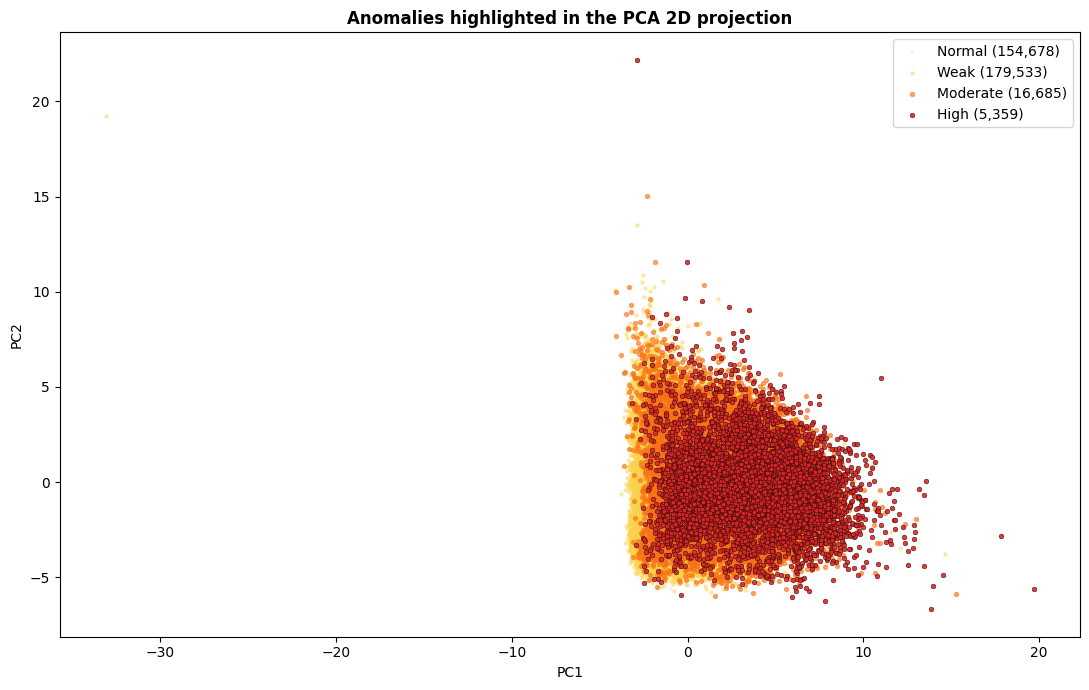

Saved pca_anomaly_sample.csv (34,857 rows for the dashboard)


In [6]:
# PCA scatter with anomalies highlighted
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca.fit_transform(X_scaled)
merged_a_indexed = merged_a.reset_index(drop=True)
merged_a_indexed['PC1'] = X_pca2[:, 0]
merged_a_indexed['PC2'] = X_pca2[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
normal = merged_a_indexed[merged_a_indexed['anomaly_category']=='NORMAL']
weak = merged_a_indexed[merged_a_indexed['anomaly_category']=='WEAK_SIGNAL']
moderate = merged_a_indexed[merged_a_indexed['anomaly_category']=='MODERATE_ANOMALY']
high = merged_a_indexed[merged_a_indexed['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
ax.scatter(normal['PC1'], normal['PC2'], c='#CCCCCC', s=3, alpha=0.2, label=f'Normal ({len(normal):,})')
ax.scatter(weak['PC1'], weak['PC2'], c='#FCD34D', s=5, alpha=0.4, label=f'Weak ({len(weak):,})')
ax.scatter(moderate['PC1'], moderate['PC2'], c='#F97316', s=8, alpha=0.6, label=f'Moderate ({len(moderate):,})')
ax.scatter(high['PC1'], high['PC2'], c='#DC2626', s=12, alpha=0.9, label=f'High ({len(high):,})', edgecolors='black', linewidths=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Anomalies highlighted in the PCA 2D projection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_pca_anomaly.png', dpi=150)
plt.show()

# Export a sample for the Phase 5 dashboard (all HIGH plus a sample of the rest)
high_idx = np.where(merged_a_indexed['anomaly_category'] == 'HIGH_CONFIDENCE_ANOMALY')[0]
rng_exp = np.random.default_rng(RANDOM_SEED)
base_idx = rng_exp.choice(len(merged_a_indexed), size=min(30000, len(merged_a_indexed)), replace=False)
keep_idx = np.unique(np.concatenate([base_idx, high_idx]))
merged_a_indexed.iloc[keep_idx][['PC1', 'PC2', 'anomaly_category', 'CLUSTER_KMEANS']].to_csv(
    OUT_DIR / 'pca_anomaly_sample.csv', index=False)
print(f'Saved pca_anomaly_sample.csv ({len(keep_idx):,} rows for the dashboard)')

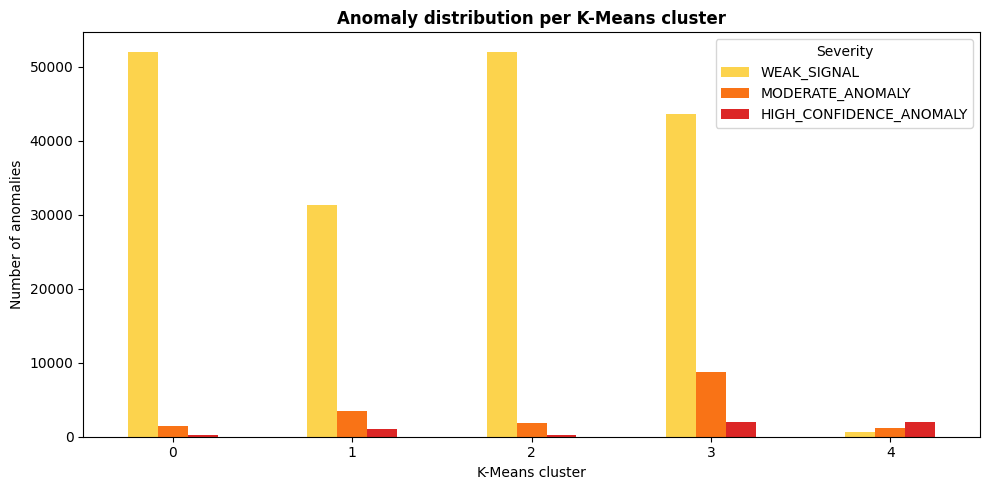

In [7]:
# Anomalies per cluster (heatmap-like bar)
cluster_anomalies = merged_a.groupby('CLUSTER_KMEANS')['anomaly_category'].value_counts().unstack(fill_value=0)
if 'NORMAL' in cluster_anomalies.columns:
    cluster_anomalies = cluster_anomalies.drop(columns=['NORMAL'])
cluster_anomalies_sorted = cluster_anomalies.reindex(columns=['WEAK_SIGNAL','MODERATE_ANOMALY','HIGH_CONFIDENCE_ANOMALY'])
fig, ax = plt.subplots(figsize=(10, 5))
cluster_anomalies_sorted.plot(kind='bar', stacked=False, ax=ax,
                              color=['#FCD34D','#F97316','#DC2626'])
ax.set_xlabel('K-Means cluster'); ax.set_ylabel('Number of anomalies')
ax.set_title('Anomaly distribution per K-Means cluster', fontweight='bold')
ax.legend(title='Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_per_cluster.png', dpi=150)
plt.show()

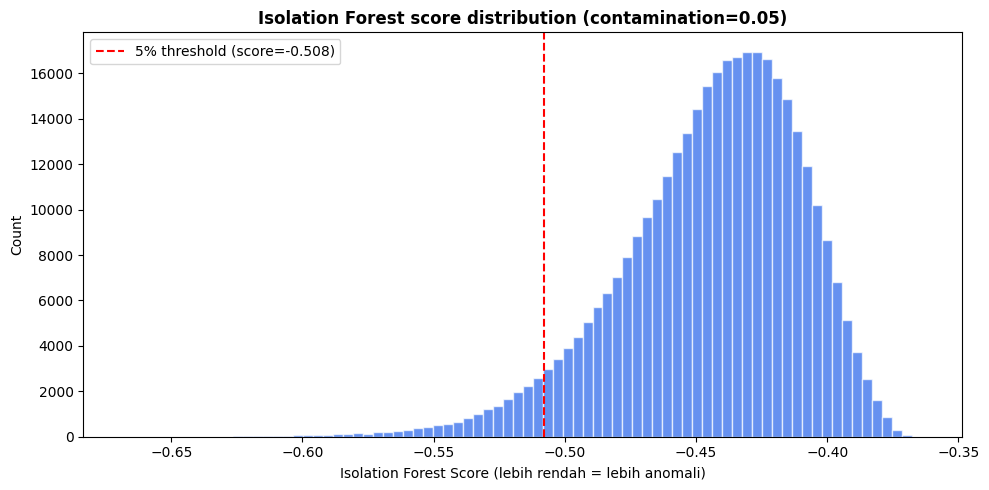

In [8]:
# Isolation Forest score distribution + threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_df['isolation_score'], bins=80, color='#2563EB', alpha=0.7, edgecolor='white')
thr05 = iso_df['isolation_score'].quantile(DEFAULT_CONTAM)
ax.axvline(thr05, color='red', ls='--', label=f'5% threshold (score={thr05:.3f})')
ax.set_xlabel('Isolation Forest Score (lebih rendah = lebih anomali)')
ax.set_ylabel('Count')
ax.set_title(f'Isolation Forest score distribution (contamination={DEFAULT_CONTAM})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_isolation_score_dist.png', dpi=150)
plt.show()

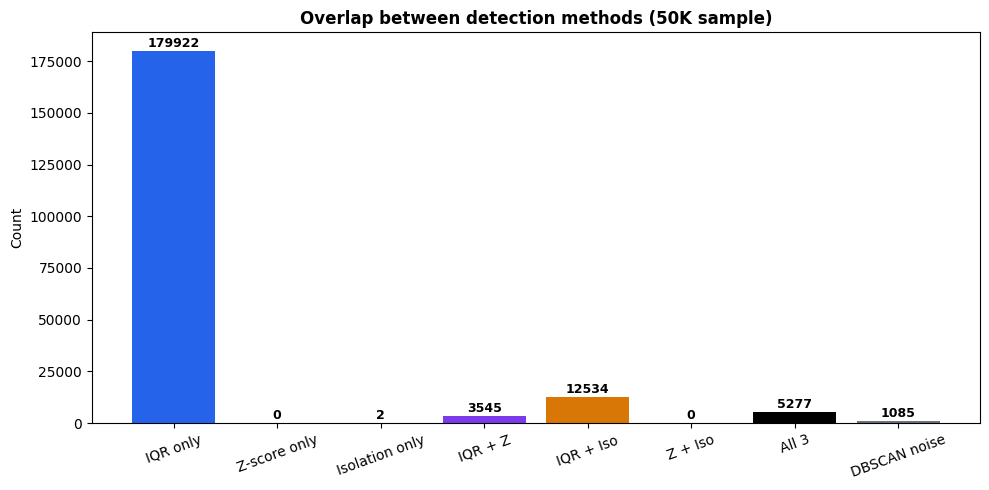

In [9]:
# Method overlap (Venn-ish bar)
n_iqr = int(merged_a['is_iqr_outlier'].sum())
n_z = int(merged_a['is_zscore_outlier'].sum())
n_iso = int(merged_a['is_isolation_outlier'].sum())
n_dbscan = int(merged_a['IS_OUTLIER'].fillna(0).sum())
n_iqr_z = int((merged_a['is_iqr_outlier'] & merged_a['is_zscore_outlier']).sum())
n_iqr_iso = int((merged_a['is_iqr_outlier'] & merged_a['is_isolation_outlier']).sum())
n_z_iso = int((merged_a['is_zscore_outlier'] & merged_a['is_isolation_outlier']).sum())
n_all3 = int((merged_a['is_iqr_outlier'] & merged_a['is_zscore_outlier'] & merged_a['is_isolation_outlier']).sum())

overlap_data = [
    ('IQR only', n_iqr - n_iqr_z - n_iqr_iso + n_all3),
    ('Z-score only', n_z - n_iqr_z - n_z_iso + n_all3),
    ('Isolation only', n_iso - n_iqr_iso - n_z_iso + n_all3),
    ('IQR + Z', n_iqr_z - n_all3),
    ('IQR + Iso', n_iqr_iso - n_all3),
    ('Z + Iso', n_z_iso - n_all3),
    ('All 3', n_all3),
    ('DBSCAN noise', n_dbscan),
]
fig, ax = plt.subplots(figsize=(10, 5))
labels_o = [x[0] for x in overlap_data]
vals_o = [x[1] for x in overlap_data]
colors_o = ['#2563EB','#059669','#DC2626','#7C3AED','#D97706','#F97316','#000','#6B7280']
bars = ax.bar(labels_o, vals_o, color=colors_o)
for bar, v in zip(bars, vals_o):
    ax.text(bar.get_x()+bar.get_width()/2, v+max(vals_o)*0.01, str(v), ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Overlap between detection methods (50K sample)', fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_method_overlap.png', dpi=150)
plt.show()

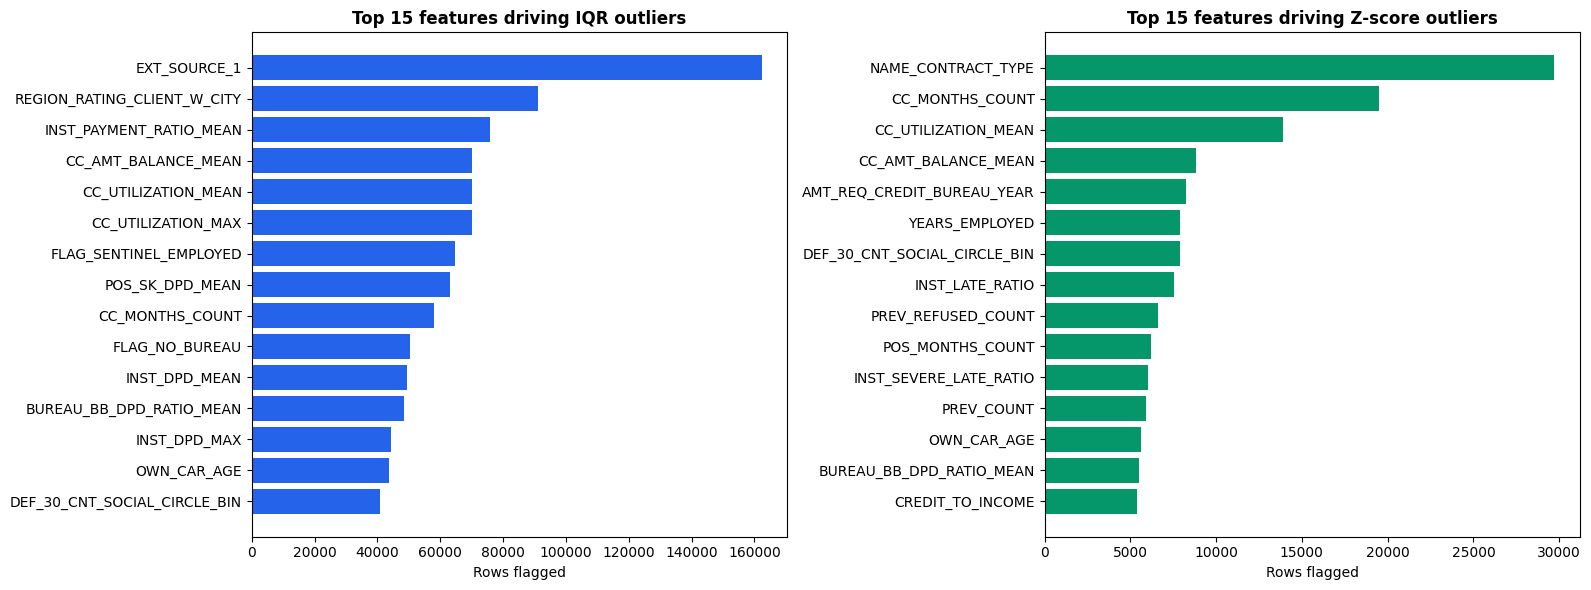

In [10]:
# Heatmap: features that drive anomalies the most
top_iqr_feats = iqr_flags.sum().sort_values(ascending=False).head(15)
top_z_feats = z_flags.sum().sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_iqr_feats.index[::-1], top_iqr_feats.values[::-1], color='#2563EB')
axes[0].set_title('Top 15 features driving IQR outliers', fontweight='bold')
axes[0].set_xlabel('Rows flagged')
axes[1].barh(top_z_feats.index[::-1], top_z_feats.values[::-1], color='#059669')
axes[1].set_title('Top 15 features driving Z-score outliers', fontweight='bold')
axes[1].set_xlabel('Rows flagged')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_heatmap.png', dpi=150)
plt.show()

---
Phase 4 done. The artefacts are in `results/phase4_anomaly/`.